<a href="https://colab.research.google.com/github/taihlework-prog/PMC3k_SC/blob/c/PMC3k_SC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Seurat-Guided Clustering
##Set up the Seurat Object
* PBMC: dataset of Peripheral Blood Mononuclear Cells
* Read10X() function: reads in the output of the cellranger pipeline from 10X, returning a unique molecular identified (UMI) count matrix.
* Values in matrix: row-number of molecular for each feature (gene), column-features in each cell.
(if h5 file format -> using the Read10X_h5()function)
* Seurat object: a container that contain both data (in this case: count matrix) and analysis (PCA or clustering result)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!apt-get install r-base
%load_ext rpy2.ipython

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base is already the newest version (4.5.2-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [4]:
%%R
install.packages("dplyr")
install.packages("Seurat")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/dplyr_1.1.4.tar.gz'
Content type 'application/x-gzip' length 1207521 bytes (1.2 MB)
downloaded 1.2 MB


The downloaded source packages are in
	‘/tmp/RtmpbrDUqa/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘bitops’, ‘dotCall64’, ‘gtools’, ‘caTools’, ‘plyr’, ‘tensor’, ‘BH’, ‘sitmo’, ‘sp’, ‘spam’, ‘globals’, ‘listenv’, ‘parallelly’, ‘zoo’, ‘lazyeval’, ‘crosstalk’, ‘RcppTOML’, ‘here’, ‘gplots’, ‘reshape2’, ‘gridExtra’, ‘RcppArmadillo’, ‘spatstat.data’, ‘spatstat.univar’, ‘spatstat.random’, ‘spatstat.utils’, ‘spatstat.sparse’, ‘goftest’, ‘abind’, ‘deldir’, ‘polyclip’, ‘FNN’, ‘dqrng’, ‘SeuratObject’, ‘cowplot’, ‘fastDummies’, ‘fitdistrplus’, ‘future’, ‘future.apply’, ‘ggrepel’, ‘ggridges’, ‘ica’, ‘igraph’, ‘irlba’, ‘leidenbase’, ‘lmtest’, ‘matrixStats’, ‘patchwork’, ‘pbappl

In [5]:
%%R
install.packages("patchwork")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/patchwork_1.3.2.tar.gz'
Content type 'application/x-gzip' length 3322521 bytes (3.2 MB)
downloaded 3.2 MB


The downloaded source packages are in
	‘/tmp/RtmpbrDUqa/downloaded_packages’


In [6]:
%%R
library (dplyr)
library (Seurat)
library (patchwork)


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Loading required package: SeuratObject
Loading required package: sp

Attaching package: ‘SeuratObject’

The following objects are masked from ‘package:base’:

    intersect, t



In [7]:
%%R
# Load the PMC dataset
pbmc.data <- Read10X(data.dir ="/content/drive/MyDrive/10_reproduce_omics_studies/PBMC3k_SingleCell/filtered_gene_bc_matrices/hg19/")

In [8]:
%%R
# Initialize the Seurat object with the raw (non-normalized data)
pbmc <- CreateSeuratObject(counts = pbmc.data, project = "pbmc3k", min.cells = 3, min.features = 200)
pbmc

An object of class Seurat 
13714 features across 2700 samples within 1 assay 
Active assay: RNA (13714 features, 0 variable features)
 1 layer present: counts


What does data in a count matrix look like?



In [9]:
%%R
# Lets examine a few genes in the first thirty cells
pbmc.data[c("CD3D", "TCL1A", "MS4A1"), 1:30]

3 x 30 sparse Matrix of class "dgCMatrix"
                                                                   
CD3D  4 . 10 . . 1 2 3 1 . . 2 7 1 . . 1 3 . 2  3 . . . . . 3 4 1 5
TCL1A . .  . . . . . . 1 . . . . . . . . . . .  . 1 . . . . . . . .
MS4A1 . 6  . . . . . . 1 1 1 . . . . . . . . . 36 1 2 . . 2 . . . .


  [[ suppressing 30 column names ‘AAACATACAACCAC-1’, ‘AAACATTGAGCTAC-1’, ‘AAACATTGATCAGC-1’ ... ]]


The . values in the matrix represent 0s (no molecules detected). Since most values in an scRNA-seq matrix are 0, Seurat uses a sparse-matrix representtion whenever possible. This results in significant memory and speed savings for Drop-seq/inDrop/10x data.

In [10]:
%%R
dense.size <- object.size(as.matrix(pbmc.data))
dense.size

709591472 bytes


In [11]:
%%R
sparse.size <- object.size(pbmc.data)
sparse.size

29905192 bytes


In [12]:
%%R
dense.size/sparse.size

23.7 bytes


##Standard pre-processing workflow
These steps below encompass the standard pre-processing workfow for scRNA-seq data in Seurat. Including:
1. QC-Quality control: selection and filtration of cells
2. Data normalization and Scaling
3.  Detection of highly variable features

###QC and selecting cells
QC metrics commonly used:
1. The number of unique genes detected in each cell
  * Low-quality cells or empty droplets -> very few genes
  * Cell doublets or multiplets may exhibit an aberrantly high gene count
2. Total number of molecules within a cell (correlates strongly with unique genes)
3. Percentage of reads that map to the mitochondrial genome
* Low-quality/dying cells often exhibit extensive mitochondrial contamination
* Calculate mitochondrial QC metrics with PercentageFeatureSet() function: calculates the percentage of counts originating from a set of features
* Use the set of all genes starting with MT- as a set of mitochondrial genes.

In [13]:
%%R
# The [[]]operator can add columns to object metadata. This is a great place to stash QC statts
pbmc[["percent.mt"]] <- PercentageFeatureSet(pbmc, pattern = "^MT-")

###Where are QC metrics stored in Seurat
* The number of unique genes and total molecules are automatically calculated during CreatSeuratObject()
  * We can find them stored in the object meta data

In [14]:
%%R
# Show QC metrics for the first 5 cells
head(pbmc@meta.data, 5)

                 orig.ident nCount_RNA nFeature_RNA percent.mt
AAACATACAACCAC-1     pbmc3k       2419          779  3.0177759
AAACATTGAGCTAC-1     pbmc3k       4903         1352  3.7935958
AAACATTGATCAGC-1     pbmc3k       3147         1129  0.8897363
AAACCGTGCTTCCG-1     pbmc3k       2639          960  1.7430845
AAACCGTGTATGCG-1     pbmc3k        980          521  1.2244898


Now, we visulize QC metrics, following 3 criteria (genes in each cell, molecules within a cell, mitochondrail genome)
* We filter cells that have unique feature counts over 2,500 or less than 200
* We filter cells that have >5% mitochondrial counts

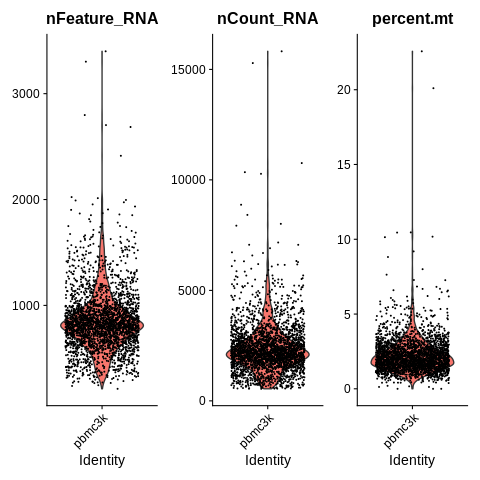

In [16]:
%%R
# Visualize QC metrics as a violin plot
VlnPlot(pbmc, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol =3)

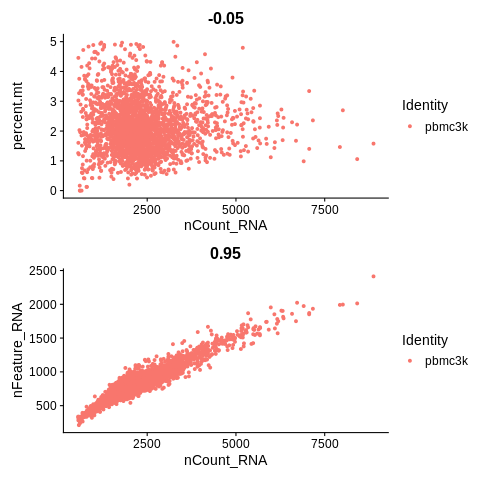

In [25]:
%%R
# FeatureScatter is typically used to visualize feature-feature relationships, but can be used
# for anything calculated by the object, i.e. columns in object metadata, PC scores etc.
plot1 <- FeatureScatter(pbmc, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(pbmc, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1/plot2

In [19]:
%%R
# Remove unqualified cells
pbmc <- subset(pbmc, subset = nFeature_RNA > 200 & nFeature_RNA < 2500 & percent.mt < 5)

##Normalizing the data
This step after removing unwanted cells. "LogNormalize" that normalizes the feature expression measurements for each cell by the total expression, multiplies this by a scale factor (10,000 by default) and log-transforms the result.

In [20]:
%%R
pbmc <- NormalizeData (pbmc, normalization.method = "LogNormalize", scale.factor = 10000)

Normalizing layer: counts
Performing log-normalization
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|


Above is method called "global-scaling". This method relies on an assumption that each cell originally contains the same number of RNA molecules.
Different method: SCTransform will replace the need to run NormalizeData, FindVariableFeatures, or ScaleData

## Identification of highly variable features (feature selection)
Calculate a subset of features that exhibit high cell-to-cell variation in the dataset or low. Focusing on these genes in downstream analysis helps to highlight bbiological signal in single-cell datasets

Finding variable features for layer counts
Calculating gene variances
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Calculating feature variances of standardized and clipped values
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
When using repel, set xnudge and ynudge to 0 for optimal results


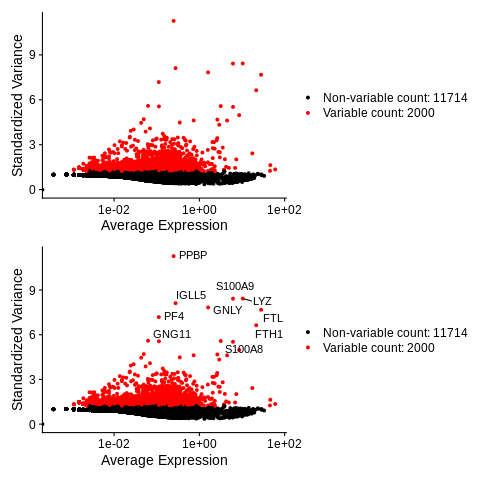

In [24]:
%%R
pbmc <- FindVariableFeatures(pbmc, selection.method = "vst", nfeatures = 2000)
#Identify the 10 most highly variable genes
top10 <- head(VariableFeatures(pbmc), 10)
# plot variable features with and without labels
plot1 <- VariableFeaturePlot(pbmc)
plot2 <- LabelPoints(plot = plot1, points = top10, repel = TRUE)
plot1/plot2

##Scaling the data
Scaling is linear transformation that is a standard pre-processing step prior to dimensional reduction techniques like PCA.\
The ScaleData() function:
* Shifts the expression of each gene, so that the mean expression across cells is 0
* Scales the expression of each gene, so that the variance across cells is 1
  * This step gives equal weight in downstream analyses, so that highly-expressed genes do not dominate
* The result of this are stored in pbmc[["RNA"]]$scale.data
* By default, only variable features are scaled

In [26]:
%%R
all.genes <- rownames(pbmc)
pbmc <- ScaleData(pbmc, features = all.genes)

Centering and scaling data matrix
  |======================================================================| 100%


##Perform linear dimensional reduction
Perform PCA on the scaled data\
For the first PCA, Seurat outputs a list of genes with the most positive and negative loadings, representing modules of genes that exhibit either correlation (or anti-correlation) across sigle-cells in a dataset.

In [27]:
%%R
pbmc <- RunPCA(pbmc, features = VariableFeatures(object = pbmc))

PC_ 1 
Positive:  CST3, TYROBP, LST1, AIF1, FTL, FTH1, LYZ, FCN1, S100A9, TYMP 
	   FCER1G, CFD, LGALS1, S100A8, CTSS, LGALS2, SERPINA1, IFITM3, SPI1, CFP 
	   PSAP, IFI30, SAT1, COTL1, S100A11, NPC2, GRN, LGALS3, GSTP1, PYCARD 
Negative:  MALAT1, LTB, IL32, IL7R, CD2, B2M, ACAP1, CD27, STK17A, CTSW 
	   CD247, GIMAP5, AQP3, CCL5, SELL, TRAF3IP3, GZMA, MAL, CST7, ITM2A 
	   MYC, GIMAP7, HOPX, BEX2, LDLRAP1, GZMK, ETS1, ZAP70, TNFAIP8, RIC3 
PC_ 2 
Positive:  CD79A, MS4A1, TCL1A, HLA-DQA1, HLA-DQB1, HLA-DRA, LINC00926, CD79B, HLA-DRB1, CD74 
	   HLA-DMA, HLA-DPB1, HLA-DQA2, CD37, HLA-DRB5, HLA-DMB, HLA-DPA1, FCRLA, HVCN1, LTB 
	   BLNK, P2RX5, IGLL5, IRF8, SWAP70, ARHGAP24, FCGR2B, SMIM14, PPP1R14A, C16orf74 
Negative:  NKG7, PRF1, CST7, GZMB, GZMA, FGFBP2, CTSW, GNLY, B2M, SPON2 
	   CCL4, GZMH, FCGR3A, CCL5, CD247, XCL2, CLIC3, AKR1C3, SRGN, HOPX 
	   TTC38, APMAP, CTSC, S100A4, IGFBP7, ANXA1, ID2, IL32, XCL1, RHOC 
PC_ 3 
Positive:  HLA-DQA1, CD79A, CD79B, HLA-DQB1, HLA-DPB1, HLA-DPA

In [28]:
%%R
#Examine and visualize PCA results a few different ways
print (pbmc[["pca"]], dims = 1:5, nfeatures = 5)

PC_ 1 
Positive:  CST3, TYROBP, LST1, AIF1, FTL 
Negative:  MALAT1, LTB, IL32, IL7R, CD2 
PC_ 2 
Positive:  CD79A, MS4A1, TCL1A, HLA-DQA1, HLA-DQB1 
Negative:  NKG7, PRF1, CST7, GZMB, GZMA 
PC_ 3 
Positive:  HLA-DQA1, CD79A, CD79B, HLA-DQB1, HLA-DPB1 
Negative:  PPBP, PF4, SDPR, SPARC, GNG11 
PC_ 4 
Positive:  HLA-DQA1, CD79B, CD79A, MS4A1, HLA-DQB1 
Negative:  VIM, IL7R, S100A6, IL32, S100A8 
PC_ 5 
Positive:  GZMB, NKG7, S100A8, FGFBP2, GNLY 
Negative:  LTB, IL7R, CKB, VIM, MS4A7 


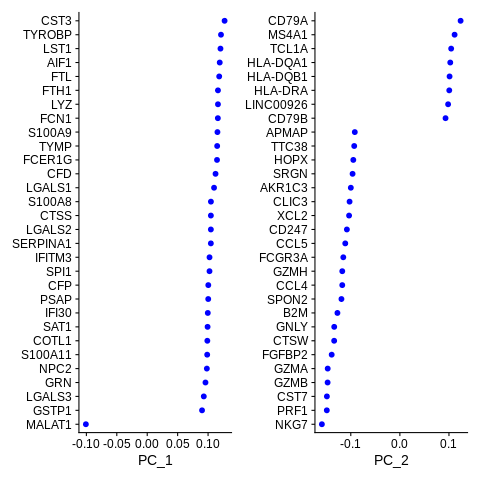

In [30]:
%%R
VizDimLoadings(pbmc, dims = 1:2, reduction = "pca")

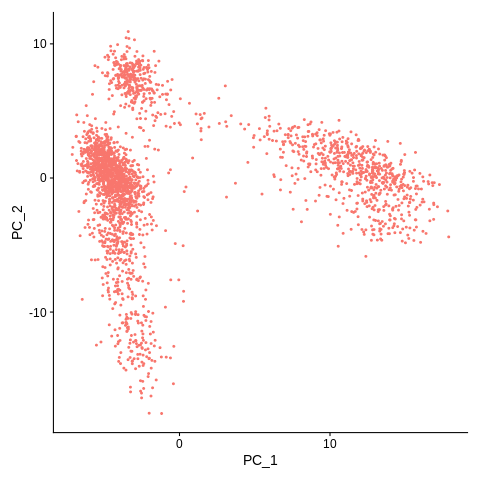

In [31]:
%%R
DimPlot(pbmc, reduction = "pca") + NoLegend()

Heatmap allow exploration of the primary sources of heterogeneity in a dataset, and can be useful when trying to decide which PCs to include for further downstream analyses.

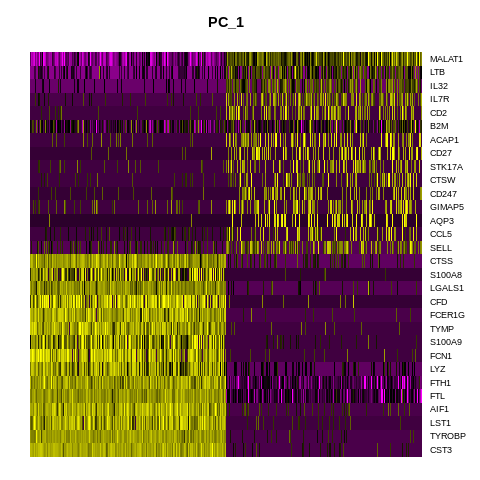

In [32]:
%%R
DimHeatmap(pbmc,dims = 1, cells = 500, balanced = TRUE)

Cells and features are ordered based on their PCA scores. Setting cells to a number plots the 'extreme' cells on both end of the spectrum, which dramatically speeds plotting for large datasets.

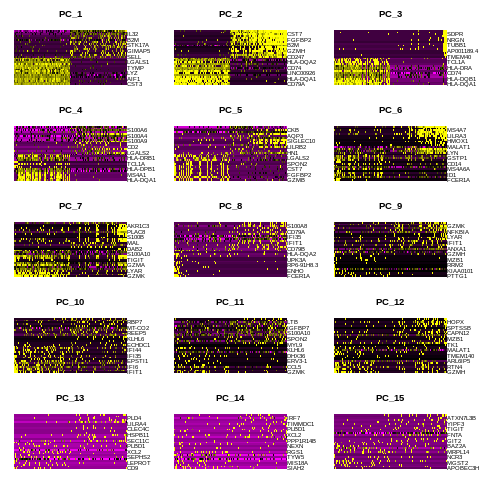

In [33]:
%%R
DimHeatmap(pbmc, dims = 1:15, cells = 500, balanced = TRUE)

##Determine the 'dimensionality' of the dataset
Seurat clusters cells based on their PCA scores, with each PC essentially representing a 'metafeature' that combines information across a correlated feature set. Question is: how many components should we include? 10? 20? 100?
Use ElbowPlot() function to determine. The point where the curve starts to divert seems to be an optimal number of PCs.

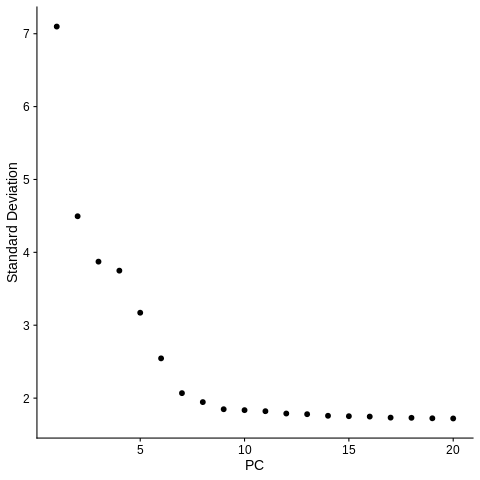

In [34]:
%%R
ElbowPlot(pbmc)

As we can see above 10, there is no divertion -> suggest that we should choose the first 10 PCs.

Identifying can be uncertain. We should therefore use multiple approaches
* The first is more supervised: explore PCs to determine relevant sources of heterogeneity, and could be used in conjuction with GSEA.
* The second: ElbowPlot
* The third: a heuristic\

Choose 10 here, but:
* Dendritic cell and NK aficinados may recognize that genes strongly associated with PCs 12 and 13 define rare immune subset (MZB1 is a marker for plasmacytoid DCs). But these groups are so rare.
* Might repeat downstream analyses wih a different number of PCs: 10, 15, 50, the results we observe do not differ dramatically
* Should choose higher PCs, not 5 because can create adverse affects.

---
##Cluster the cells

###Method:
Embed cells in a graph structure - example a K-nearest neighbor (KNN) graph, with edges drawn between cells with similar feature expression patterns and then attempt to partition this graph into highly interconnected 'quasicliques' or 'communities'

FindNeighbors() function: refine the edge weights between any two cells based on the shared overlap in their local neighborhoods (Jaccard similarity), with the aim of constructing a KNN graph based on the euclidean distance in PCA space. Input: first 10PCs

FindClusters() function: iteratively group cells together aiming of optimizing the standard modularity function. Modularity optimization techniques: Louvain algorithm or SLM. Result of this function contains a resolution parameter that sets the 'granularity' of the downstream clustering, with increased values leading to a greater number of clusters. Authors suggest that resolution should be set from 0.4-1.2.

In [35]:
%%R
pbmc <- FindNeighbors(pbmc, dims = 1:10)
pbmc <- FindClusters(pbmc, resolution = 0.5)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2638
Number of edges: 95965

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8723
Number of communities: 9
Elapsed time: 0 seconds


Computing nearest neighbor graph
Computing SNN
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|


In [37]:
%%R
# Look at cluster IDs of the first 5 cells
head(Idents(pbmc), 5)

AAACATACAACCAC-1 AAACATTGAGCTAC-1 AAACATTGATCAGC-1 AAACCGTGCTTCCG-1 
               2                3                2                1 
AAACCGTGTATGCG-1 
               6 
Levels: 0 1 2 3 4 5 6 7 8


###Run non-linear dimensional reduction (UMAP/tSNE)
tSNE and UMAP are two non-linear dimensional reduction techniques (PCA is linear reduction) to visualize datasets. The goal is to place similar cells together in low-dimensional space. Therefore, cells that are grouped within graph-based clusters determined above should co-locolize on these dimension reduction plots

Avoid drawing biological conclusions solely on the visualization. Why? Search for their limitations. These methods aim to preserve local distances in the dataset but do not preserve more global relationship (heatmap)

In [38]:
%%R
pbmc <- RunUMAP(pbmc, dims = 1:10)

To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session
20:08:43 UMAP embedding parameters a = 0.9922 b = 1.112
20:08:43 Read 2638 rows and found 10 numeric columns
20:08:43 Using Annoy for neighbor search, n_neighbors = 30
20:08:43 Building Annoy index with metric = cosine, n_trees = 50
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
20:08:43 Writing NN index file to temp file /tmp/RtmpbrDUqa/file1d541cc17fa
20:08:43 Searching Annoy index using 1 thread, search_k = 3000
20:08:44 Annoy recall = 100%
20:08:46 Commencing smooth kNN distance calibration using 1 thread with target n_neighbors = 30
20:08:47 Initializing from normalized Laplacian + noise (using RSpectra)
20:08:47 Commencing optimization for 500 epochs, with 105124 positive edges
20:08:47 Using rng type: pcg
Using method 'umap'
0%   10

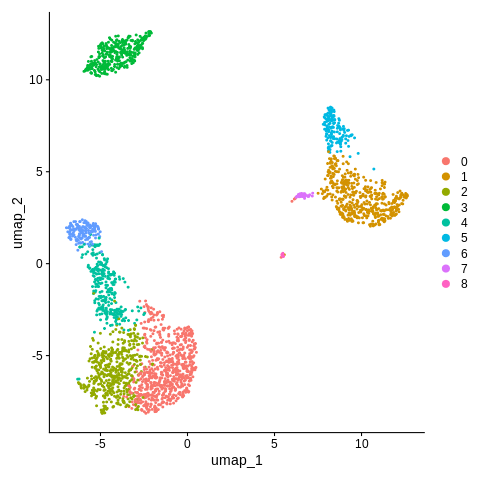

In [39]:
#note that we can set 'label=TRUE' or use the LabelClusters function to help label
#individual clusters
%%R
DimPlot(pbmc, reduction="umap")

###Finding differentially expressed features (cluster biomarkers)
Seurat can help you find markers that define clusters via differential expression (DE). By default, it identifies positive and negative markers of a single cluster (specified in ident.1), compared to all other cells. FindAllMarkers() automates this process for all clusters, but you can also test groups of clusters vs. each other, or against all cells.

In [42]:
#find all markers of cluster 2
%%R
cluster2.markers <- FindMarkers(pbmc, ident.1 = 2)
head(cluster2.markers, n=5)

  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=02m 25s
            p_val avg_log2FC pct.1 pct.2    p_val_adj
IL32 2.593535e-91  1.3221171 0.949 0.466 3.556774e-87
LTB  7.994465e-87  1.3450377 0.981 0.644 1.096361e-82
CD3D 3.922451e-70  1.0562099 0.922 0.433 5.379250e-66
IL7R 1.130870e-66  1.4256944 0.748 0.327 1.550876e-62
LDHB 4.082189e-65  0.9765875 0.953 0.614 5.598314e-61


For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session


In [43]:
%%R
#find all markers distinguishing cluster 5 from clusters 0 and 3
cluster5.markers <- FindMarkers (pbmc, ident.1 = 5, ident.2 = c(0,3))
head(cluster5.markers, n=5)

  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=01m 30s
                      p_val avg_log2FC pct.1 pct.2     p_val_adj
FCGR3A        2.150929e-209   6.832372 0.975 0.039 2.949784e-205
IFITM3        6.103366e-199   6.181000 0.975 0.048 8.370156e-195
CFD           8.891428e-198   6.052575 0.938 0.037 1.219370e-193
CD68          2.374425e-194   5.493138 0.926 0.035 3.256286e-190
RP11-290F20.3 9.308287e-191   6.335402 0.840 0.016 1.276538e-186


In [44]:
%%R
#find markers for every cluster compared to all remaining cells, report only the positive ones
pbmc.markers <- FindAllMarkers(pbmc, only.pos = TRUE)
pbmc.markers %>%
    group_by(cluster)%>%
    dplyr::filter(avg_log2FC > 1)

  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=37s  
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=40s  
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=51s  
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=43s  
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=59s  
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=50s  
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=01m 18s
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=01m 10s
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=37s  
# A tibble: 7,046 × 7
# Groups:   cluster [9]
       p_val avg_log2FC pct.1 pct.2 p_val_adj cluster gene     
       <dbl>      <dbl> <dbl> <dbl>     <dbl> <fct>   <chr>    
 1 1.74e-109       1.19 0.897 0.593 2.39e-105 0       LDHB     
 2 1.17e- 83       2.37 0.435 0.108 1.60e- 79 0       CCR7     
 3 8.94e- 79       1.09 0.83

Calculating cluster 0
Calculating cluster 1
Calculating cluster 2
Calculating cluster 3
Calculating cluster 4
Calculating cluster 5
Calculating cluster 6
Calculating cluster 7
Calculating cluster 8


ROC test returns the 'classification power' for any individual marker (ranging from 0-random, to 1-perfect)

In [45]:
%%R
cluster0.markers <- FindMarkers (pbmc, ident.1 = 0, logfc.threshold = 0.25, test.use="roc", only.pos = TRUE)


  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=08s  


In [48]:
%%R
head(cluster0.markers, n=10)

      myAUC  avg_diff power avg_log2FC pct.1 pct.2
RPS12 0.824 0.5094804 0.648  0.7439459 1.000 0.991
RPS6  0.821 0.4712446 0.642  0.6862148 1.000 0.995
RPS27 0.819 0.4996079 0.638  0.7298479 0.999 0.992
RPL32 0.815 0.4238952 0.630  0.6184804 0.999 0.995
RPS14 0.808 0.4296946 0.616  0.6283021 1.000 0.994
RPS25 0.799 0.5158742 0.598  0.7635765 0.997 0.975
RPS3  0.792 0.4224639 0.584  0.6164386 1.000 0.994
RPL9  0.792 0.5159172 0.584  0.7609592 0.994 0.971
RPL13 0.791 0.3917495 0.582  0.5694355 1.000 0.996
RPL31 0.790 0.5126928 0.580  0.7609591 0.996 0.964


VlnPlot() shows expression probability distributions across clusters

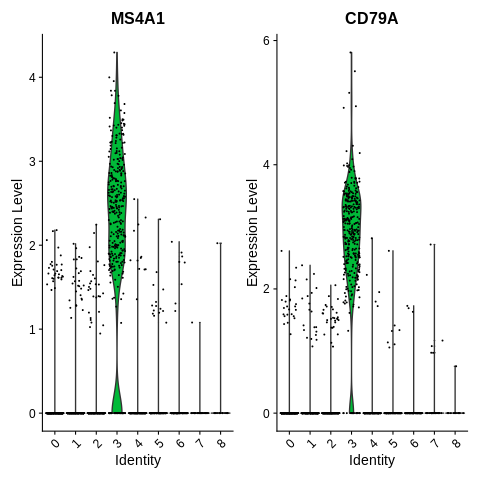

In [49]:
%%R
VlnPlot(pbmc, features = c("MS4A1", "CD79A"))

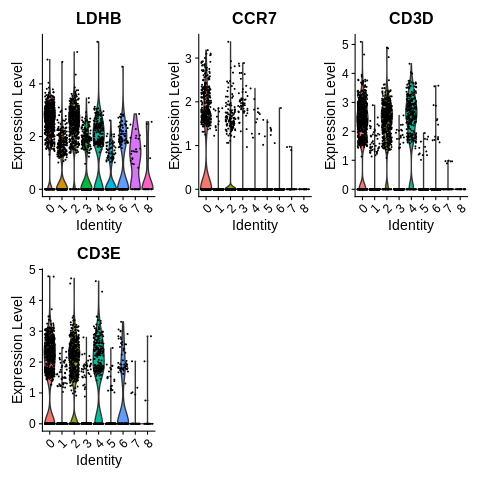

In [51]:
%%R
VlnPlot(pbmc, features = c("LDHB", "CCR7", "CD3D", "CD3E"))

In addition: Warning message:
The `slot` argument of `VlnPlot()` is deprecated as of Seurat 5.0.0.
ℹ Please use the `layer` argument instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


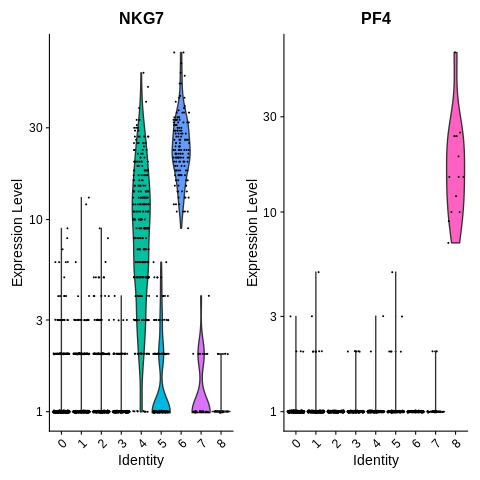

In [53]:
%%R
# you can plot raw counts as well
VlnPlot(pbmc, features = c("NKG7", "PF4"), slot = "counts", log = TRUE)

FeaturePlot() visualizes feature expression on a tSNE or PCA plot (mostly used)

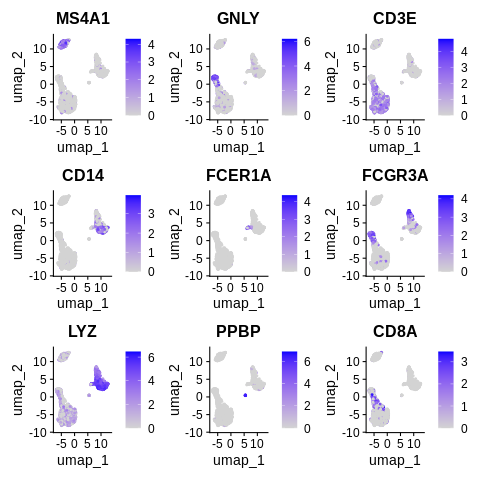

In [54]:
%%R
FeaturePlot(pbmc, features = c("MS4A1", "GNLY", "CD3E", "CD14", "FCER1A", "FCGR3A", "LYZ", "PPBP",
    "CD8A"))

RidgePlot(), CellScatter(), DotPlot()

Picking joint bandwidth of 0.0236
Picking joint bandwidth of 0.0228


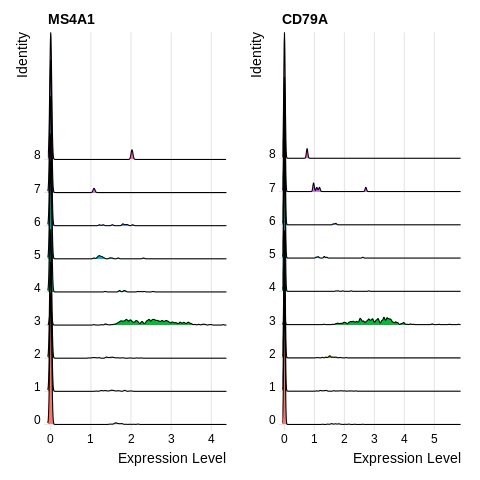

In [55]:
%%R
RidgePlot(pbmc, features = c("MS4A1", "CD79A"))

Picking joint bandwidth of 0.0236
Picking joint bandwidth of 0.0971
Picking joint bandwidth of 0.125
Picking joint bandwidth of 0.0337
Picking joint bandwidth of 0.0659
Picking joint bandwidth of 0.0872
Picking joint bandwidth of 0.319
Picking joint bandwidth of 0.033
Picking joint bandwidth of 0.0368


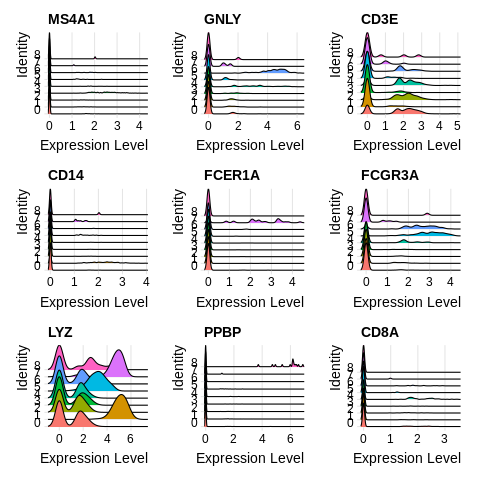

In [56]:
%%R
RidgePlot(pbmc, features = c("MS4A1", "GNLY", "CD3E", "CD14", "FCER1A", "FCGR3A", "LYZ", "PPBP",
    "CD8A"))

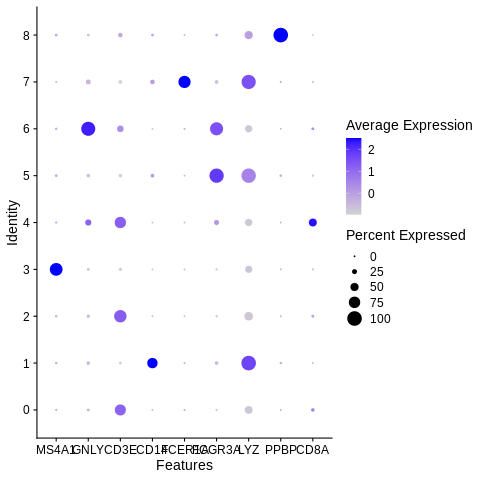

In [60]:
%%R
DotPlot(pbmc, features = c("MS4A1", "GNLY", "CD3E", "CD14",
                           "FCER1A", "FCGR3A", "LYZ", "PPBP", "CD8A"))

DoHeatmap() generates an expression heatmapp for given cells and features.

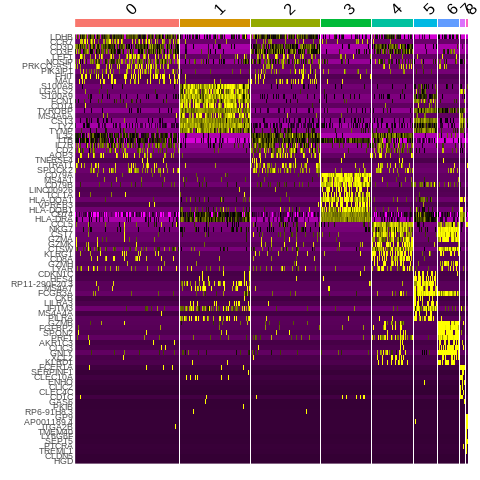

In [61]:
#Plot the top 20 markers for each cluster
%%R
pbmc.markers %>%
    group_by(cluster)%>%
    dplyr::filter(avg_log2FC > 1)%>%
    slice_head(n=10)%>%
    ungroup() -> top10
DoHeatmap(pbmc, features = top10$gene)+NoLegend()

###Assigning cell type identity to clusters
|Cluster ID|Markers|Cell Type|
|----------|-------|---------|
|0|IL7R, CCR7|Naive CD4+ T|
|1|CD14,LYZ|CD14+ Mono|
|2|IL7R,S100A4|Memory CD4+|
|3|MS4A1|B|
|4|CD8A|CD8+T|
|5|FCGR3A,MS4A7|FCGR3A+Mono|
|6|GNLY,NKG7|NK|
|7|FCER1A,CST3|DC|
|8|PPBP|Platelet|

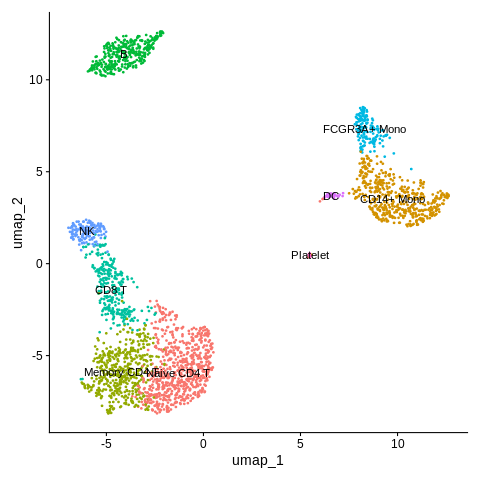

In [62]:
%%R
new.cluster.ids <- c("Naive CD4 T", "CD14+ Mono", "Memory CD4 T", "B", "CD8 T", "FCGR3A+ Mono",
    "NK", "DC", "Platelet")
names(new.cluster.ids) <- levels(pbmc)
pbmc <- RenameIdents(pbmc, new.cluster.ids)
DimPlot(pbmc, reduction = "umap", label = TRUE, pt.size = 0.5) + NoLegend()

In [64]:
%%R
library(ggplot2)
plot <- DimPlot(pbmc, reduction = "umap", label = TRUE, label.size = 4.5) + xlab("UMAP 1") + ylab("UMAP 2") +
    theme(axis.title = element_text(size = 18), legend.text = element_text(size = 18)) + guides(colour = guide_legend(override.aes = list(size = 10)))
ggsave(filename = "../output/images/pbmc3k_umap.jpg", height = 7, width = 12, plot = plot, quality = 50)

Cannot find directory '../output/images'.
ℹ Would you like to create a new directory?

1: Yes
2: No

Selection: 1
✔ Created directory: '../output/images'.
